## 0. What are we looking at?

### 0.1 Jupyter Notebook

This is a Jupyter Notebook. It contains code which can be executed and text like this one. The text can be markdown (like here) which allows for **simple** _markup_ but can also contain HTML code, the basis for every website. With HTML we can not only write text, but also insert pictures:
<center><img src="https://images3.memedroid.com/images/UPLOADED716/658586af658f0.webp" width="400"></center>

A jupyter notebook is divided into cells. Each cell can be executed seperately. This is the fifth cell of the notebook, again a markdown cell. 

The following cell is a Python code cell. A code cell can include code to be executed and comments which are not executed. Comments start with a hashtag #. 

To **execute code in the cell**, step on it and press **Cmd/Ctrl + Enter** or use the **'play button'**.

In [ ]:
# I am a comment because I start with a '#'. I am not executed.
print("Hello I am a Python Code cell. I print whatever is in these brackets!")

Another useful short — **Shift+Enter**. It executes the shell and moves on to the next. Useful when you need to click through many cells. You can always add new cells.

All cells marked with 🚀 indicate that the cell below either expects some user input or that the code below can be changed according to the instructions.

### 0.2 JupyterHub

We are running the notebook on a **Jupyter Hub**, an environment designed specifically so that multiple people can run their code on an external computer (this one is run by the University of Potsdam). 

Like this, you don't have to install Python, its libraries and an environment to write code on your own computer 👍.

But since, you're not using your own computer, you need to upload the data your working with 👎.

Also, if you don't have an UP account you can't run your notebook here. You will still be able to run it on your local machine or on [google colab](https://colab.research.google.com/).

# Processing Natural Language Data with Python 🐍 🚀

### Information to be extracted
There are various information we can extract from text and the information can be extracted in various ways. We are going to focus on the following information in this session:
1. Word frequencies on untokenised text
3. Word frequencies of tokenised text: of lemmata, without stop words, per PoS-Tag
4. Adjective-Noun Collocations
6. Named Entities


### Possible analyses
With these information we can perform a series of analyses:
1. Increase/decrease in frequency of a word or a word group (e.g. a semantic field)
2. Variety of locations/organisations
3. Increase/decrease of specific locations/organisations
4. Change in attributes of specific words or a word group 

### Steps to be performed
For this a series of steps needs to be performed:
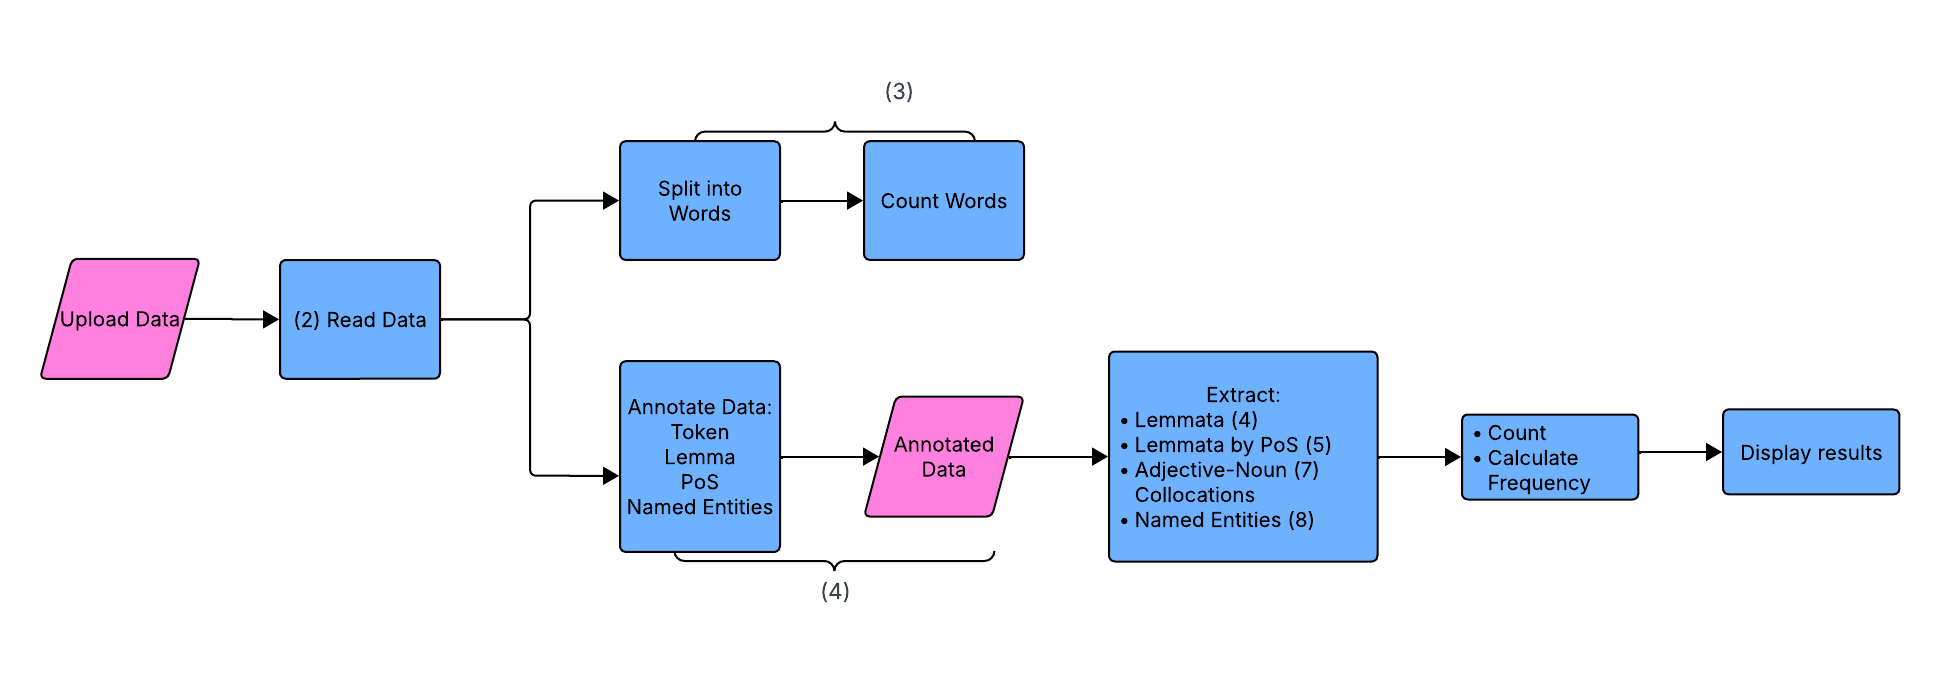

## 1. Load Python Libraries

To be able to perform these steps, some prerequisites need to be met:
* Libraries installed
* Libraries imported

In [ ]:
#  Install libraries 
! pip install tqdm pandas numpy spacy wordcloud matplotlib

#  Load English language model for annotation
! python -m spacy download en_core_web_sm

In [ ]:
# load libraries 
import typing
import requests
from pathlib import Path
from time import time
from collections import OrderedDict, Counter

from tqdm import tqdm
import pandas as pd
import numpy as np
import spacy
from wordcloud import WordCloud
import matplotlib.pyplot as plt

## 2. Read in a single text

In [ ]:
# Create data directory path
corpus_dir = Path("./")
if not corpus_dir.exists():
    print("The directory does not exist, please check the path again.")

In [ ]:
# set the path to file to be processed
text_path = corpus_dir / "AA00047511_01182.txt"

In [ ]:
# read text and print some parts of the text
if text_path.is_file():
    text = text_path.read_text()
    print(f"Textauszug:\n {text[:100]}")
else:
    print("The file path does not exist. Set the variable text_path to an existing path.")

## 3. Word count on untokenised text

The simplest way to automatically split a text into words is to assume that words are separated by spaces.

In [ ]:
# split the text into words by space
words = text.split()

**Check**: What does the word list look like?

In [ ]:
# print the 100th up the 120th words
words[:20]

What is the length of the text in words?

In [ ]:
# print the length of the word list
len(words)

As can be seen, this type of ‘incorrect’ tokenisation has the disadvantage that punctuation marks are not separated from words.
The word count is therefore also inaccurate. 

Based on this word list, an initial basic frequency query can still be performed. To do this, the words are first counted. 

In [ ]:
# count the words with Counter and save the result to a variable
word_counts = Counter(words)

🚀 To check the frequency of another word, insert it into the quotation marks below

In [ ]:
# get the number of the word "sale" in the word frequencies 
word_counts["sale"]

## 4. Lemma counts of tokenised text 
In order to obtain a more precise division into words (tokenisation) and to make inflected words mappable to each other (lemmatisation), the text is annotated using the [spaCy](https://spacy.io/) library. For this, the language-specific model is loaded. We work with the less accurate but fastest spaCy model `en_core_web_sm`. 

To check which models spaCy provides, visit: https://spacy.io/models/

### 4.1 Load language model

In [ ]:
nlp = spacy.load('en_core_web_sm')

### 4.2 Annotate text

The selected text is annotated with spaCy resulting in a spaCy Doc which saves all the annotations.

In [ ]:
# get the current time to display how long the annotation took
current = time()

# annotate with spacy
doc = nlp(text)

# calculate how long the annotation and extraction took and print result
took = time() - current
print(f"The annotation took {round(took, 2)} seconds.") 

### 4.3 Extract lemma counts
Tokenisation separated punctuation marks from words. This can be seen from the length of the text. 

In [ ]:
# print the number of token of the text
len(doc)

Based on the tokenised and lemmatised text, the frequency query can be run again. Since lemmatisation has reduced inflected word forms to their basic forms, we expect the frequency of a basic word form to be higher than in the previous query. 

In [ ]:
lemmata = [token.lemma_.strip() for token in doc]

In [ ]:
# Count the words with Counter and save the result to a variable
lemma_counts = Counter(lemmata)

🚀 To check the frequency of another lemma, insert it into the quotation marks below.

In [ ]:
# get the number of the lemma "sale" in the lemma frequencies 
lemma_counts["sale"]

### 4.4 Display frequencies as WordCloud 

In [ ]:
# Create wordcloud from frequencies
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='viridis').generate_from_frequencies(lemma_counts)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Lemma Frequencies', fontsize=16)
plt.tight_layout()
plt.show()

## 5. Count lemmata by PoS-Tag
spaCy provides the universal PoS-Tag for each word. It also produces a PoS-Tag with morphological information which is saved in the `.tag` attribute. For our purposes, the universal PoS-Tag provide enough information.

In [ ]:
universal_pos = [
    'ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 
    'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 
    'SCONJ', 'SYM', 'VERB', 'X', 'SPACE'
]

for pos in universal_pos:
    print(f"{pos}: {spacy.explain(pos)}")

### 🚀 5.1 Select PoS-Tags 

In [ ]:
def get_user_input_check_against_list(check_list):
    while True:
        entities_to_extract = input(f"Please enter the labels that you would like to analyse seperated by comma.\n \
        The labels can be one of the following: {', '.join(check_list)}\n")
        labels = [label.strip() for label in entities_to_extract.split(",")]
        labels_in_list = [entry.upper() for entry in labels if entry.upper() in check_list]
        if len(labels_in_list) == len(labels):
            print("Perfect, all labels are in the list!")
            return labels_in_list
        elif len(labels_in_list) == 0:
            print("None of the labels were in the list.")
            continue
        else:
            continue_with_list = input(f"Not all labels that were entered are in the list. If you want to continue with the following list\n \
            write 'yes' else write 'no'\n: {', '.join(labels_in_list)}\n")
            if continue_with_list.lower() == "yes":
                print("Continuing with the list")
                return labels_in_list
            else:
                continue

In [ ]:
selected_pos_tags = get_user_input_check_against_list(universal_pos)

### 5.2 Extract lemmata matching any of the PoS-Tags

In [ ]:
selected_lemmata_counts = Counter([token.lemma_ for token in doc if token.pos_ in selected_pos_tags])

### 5.3 Count Lemmata 

In [ ]:
selected_lemmata_counts.most_common(20)

In [ ]:
# Create wordcloud from frequencies
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='viridis').generate_from_frequencies(selected_lemmata_counts)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Lemma Frequencies', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Stop words
Since some annotations are wrong, we might want to delete certain words from the annotated document, which should not be part of our count analysis. In the following words can be input, which are deleted in the following.

⚠️ When using spaCy, better define stopwords before annotation, otherwise it's hard to create a document from the original `Doc` (needed to process entities). 

### 6.1 Create stop word list

In [ ]:
stopwords = []

In [ ]:
def get_user_input():
    while True:
        words_to_look_up = input(f"Enter a list of unflectated words, separated by comma: ")
        words_to_look_up = [word.strip() for word in words_to_look_up.split(",")]
        check_input = input(f"Your lemma list looks like this: {words_to_look_up} \n If you want to continue type 'yes'. \
        If you want to redo your list, type 'no'")
        if check_input.lower() == "yes":
            return words_to_look_up
        else:
            continue

In [ ]:
stopwords = get_user_input()

### 6.2 Delete stop words

In [ ]:
def clean_doc(doc, stopwords) -> list[spacy.tokens.Token]:
    return [token for token in doc if token.lemma_ not in stopwords]

In [ ]:
if len(stopwords) > 0:
    cleaned_doc = clean_doc(doc, stopwords)
else:
    # attention is not a deep copy, changed to cleaned_doc result in changes to doc
    cleaned_doc = doc

### 6.3 Count lemmata without stop words by PoS-Tags

In [ ]:
selected_lemmata_frequencies_cleaned = Counter([token.lemma_ for token in cleaned_doc if token.pos_ in selected_pos_tags])
selected_lemmata_frequencies_cleaned.most_common(20)

### 6.4 Display as WordCloud 

In [ ]:
# Create wordcloud from frequencies
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='viridis').generate_from_frequencies(selected_lemmata_frequencies_cleaned)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Lemma Frequencies', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Adjective-Noun Collocations


### 7.1 Extract adjectives of most common nouns and count
Using **Dependency Parsing**, we can extract those adjectives which directly depend on a pre-defined list of nouns. Here, we extract the adjectives of the ten most common nouns of the text.

In [ ]:
nouns = [token for token in cleaned_doc if token.pos_ == 'NOUN']
noun_counts = Counter([token.lemma_ for token in nouns])
most_common_10 = [noun for noun, count in noun_counts.most_common(10)]

def extract_adj_noun_collocations_by_noun(doc, noun_list:list[str]):
    noun_adjectives = {}
    
    for noun in noun_list:
        adjectives = []
        # Find all occurrences of this noun in the doc
        for token in doc:
            if token.pos_ == 'NOUN' and token.lemma_ == noun:
                # Check for adjectives that depend on this noun
                for child in token.children:
                    if child.pos_ == 'ADJ':
                        adjectives.append(child.lemma_)
        noun_adjectives[noun] = adjectives
    return noun_adjectives

In [ ]:
noun_adjectives = extract_adj_noun_collocations_by_noun(doc, most_common_10)

### 7.2 Count Adjectives
We then count the adjectives, to see if certain attributes occur more often then others

In [ ]:
for noun, adjectives in noun_adjectives.items():
    print(noun)
    print(Counter(adjectives).most_common())
    print("\n")

### 🚀 7.3 Select Nouns
Instead of taking the most frequent nouns, we can also choose a list, for which the adjectives are extracted:

In [ ]:
chosen_nouns = get_user_input()
noun_adjectives_chosen = extract_adj_noun_collocations_by_noun(doc, chosen_nouns)
noun_adjectives_chosen

### 🚀 7.4 Adjectives
We can also search for certain adjectives and extract which nouns they are attributed to:

In [ ]:
def extract_adj_noun_collocations_by_adj(doc, adj_list:list[str]):
    noun_adjectives = {}
    
    for adj in adj_list:
        nouns = []
        # Find all occurrences of this noun in the doc
        for token in doc:
            if token.pos_ == 'ADJ' and token.lemma_ == adj:
                # Traverse up the tree to find a noun
                current = token
                while current.head != current:  # Stop at root
                    current = current.head
                    if current.pos_ == 'NOUN':
                        nouns.append(current.lemma_)
                        break 
        noun_adjectives[adj] = nouns
    return noun_adjectives

In [ ]:
chosen_adj = get_user_input()
adjectives_nouns_chosen = extract_adj_noun_collocations_by_adj(doc, chosen_adj)
adjectives_nouns_chosen

## 8. Named Entities
The following Named Entity labels are available in spaCy. 

In [ ]:
ner_labels = nlp.get_pipe("ner").labels
for ner_label in ner_labels:
    print(f"{ner_label}: {spacy.explain(ner_label)}")

### 🚀 8.1 Select the Named Entities to be extracted

In [ ]:
selected_ne_tags = get_user_input_check_against_list(ner_labels)

### 8.2 Extract the chosen entities 

In [ ]:
def extract_named_entities_by_label(doc, selected_ne_tags):
    # Create result dictionary
    named_entities = {entity:[] for entity in selected_ne_tags}
    
    # Iterate over named entities and check if the label is in the list of labels
    for ent in doc.ents:
        if ent.label_ in selected_ne_tags:
            named_entities[ent.label_].append(ent.lemma_)
    return named_entities

In [ ]:
named_entities = extract_named_entities_by_label(doc, selected_ne_tags)

### 8.3 Inspect the results

#### How many did we find?

In [ ]:
# Show the length of the lists
for label, entries in named_entities.items():
    print(f"Number of {label}:", len(entries))

**Check** the results by looking at the first entries:

In [ ]:
for label, entries in named_entities.items():
    print(label, ":", entries[:10], "\n")

#### How many unique entities did we find?

In [ ]:
# Show the number of unique entries
for label, entries in named_entities.items():
    print(f"Number of {label}:", len(set(entries)))

#### Which are the most common ones?


In [ ]:
counted_named_entities = {label: Counter(entries) for label, entries in named_entities.items()}

In [ ]:
for label, counts in counted_named_entities.items():
    print(label)
    for lemma, count in counts.most_common(5):
        print(f"{lemma}: {count}")
    print("_"*20)

# Corpus Analysis
Now, we want to execute some analyses on the entire corpus. For this, the corpus files need to be uploaded to the same directory as the single text.

## 1. Read and annotate corpus

In [ ]:
annotated_docs = {}

# Process each file
for file_path in corpus_dir.iterdir():
    if file_path.is_file() and file_path.suffix == ".txt":
        print(f"Processing: {file_path.stem}")
    
        # Read text
        text = file_path.read_text(encoding='utf-8').split("\n")
    
        # Process with spaCy
        docs = []
        for paragraph in nlp.pipe(text):
            docs.append(paragraph)
        doc = spacy.tokens.Doc.from_docs(docs)
        annotated_docs[file_path.stem] = doc

## 2. Write annotated files 

In [ ]:
outputdir = Path("./newspaper_annotations")

In [ ]:
if not outputdir.exists():
    outputdir.mkdir()

In [ ]:
for fn, annotated_doc in annotated_docs.items():
    output_fp = outputdir /Path(fn).with_suffix(".spacy")
    annotated_doc.to_disk(output_fp)

## 3. Analyse most common lemmata in the corpus by PoS-Tag

### 3.1 🚀 Select PoS-Tags

In [ ]:
selected_pos_tags_corpus = get_user_input_check_against_list(universal_pos)

In [ ]:
selected_lemmata_count_corpus = Counter([token.lemma_ for doc in annotated_docs.values()
                                        for token in doc if token.pos_ in selected_pos_tags_corpus])

In [ ]:
selected_lemmata_count_corpus.most_common(20)

In [ ]:
# Create wordcloud from frequencies
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='viridis').generate_from_frequencies(selected_lemmata_count_corpus)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Lemma Frequencies', fontsize=16)
plt.tight_layout()
plt.show()

### 3.2 Stopwords 

#### 🚀 Select stop words

In [ ]:
stopwords_corpus = []
stopwords_corpus = get_user_input()

#### Delete stop words from corpus

In [ ]:
cleaned_annotated_docs = {fn: clean_doc(doc, stopwords_corpus) for fn, doc in annotated_docs.items()}
selected_lemmata_frequencies_corpus_cleaned = Counter([token.lemma_ for doc in cleaned_annotated_docs.values()
                                        for token in doc if token.pos_ in selected_pos_tags_corpus])

# Create wordcloud from frequencies
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='viridis').generate_from_frequencies(selected_lemmata_frequencies_corpus_cleaned)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Lemma Frequencies', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Read Metadata
To be able to perform diachronic analyses, we need the information about the time of publication which is saved in the metadata file. 
First, we must upload the file to the JupyterHub. 

### 4.1 Read metadata

In [ ]:
metadata_df = pd.read_csv("corpus_sources.csv")

### 4.2 Add ID to match with corpus

In [ ]:
def remove_suffix(filename):
    return filename.split(".")[0]

In [ ]:
# take file stem (without suffix) as ID for mapping
metadata_df["file_id"] = metadata_df["filename"].apply(remove_suffix)

In [ ]:
# change data type of the date column for easier processing
metadata_df['date'] = pd.to_datetime(metadata_df['date'])

### 4.3 Inspect Metadata

In [ ]:
metadata_df.head()

## 5. Analyse semantic fields
We can analyse a group of nouns which (can) form a semantic field.


### 5.1 Select the lemmata for the semantic field

In [ ]:
semantic_field_lemmata = get_user_input()

### 5.2 Extract frequencies  
To be able to compare the counts of the semantic fields, we not only use the count of the lemmata (absolute frequency), but the relative frequency i.e. the count in relation to the overall word count of the document. 

In [ ]:
semantic_field_frequencies = []
for fn, doc in cleaned_annotated_docs.items():
    results = {"file_id": fn}
    lemmata = [token.lemma_ for token in doc]
    counted_lemmata = Counter(lemmata)
    for lemma in semantic_field_lemmata:
        # if not present, Counter returns 0
        results[lemma] = counted_lemmata[lemma] / len(lemmata)
    semantic_field_frequencies.append(results)

### 5.3 Save the frequencies to a table and combine it with the metadate

In [ ]:
semantic_field_frequencies_df = pd.DataFrame(semantic_field_frequencies)

In [ ]:
frequency_metadata_df = pd.merge(metadata_df, semantic_field_frequencies_df).set_index("date")

#### Inspect the table 

In [ ]:
frequency_metadata_df

### 5.4 Plot the development of the frequencies over time
For each word in the semantic, a line is plotted which displays the frequency per document. Like this, we can analyse how a semantic concept changes over time. 

In [ ]:
frequency_metadata_df.plot(kind="line", y = semantic_field_lemmata, figsize=(16, 8))

## 6. Analyse Adjective-Noun Collocations

### 6.1 Extract the attributes of the semantic field nouns
If other nouns should be analysed, we can insert them below, by deleting the # of the field below to execute it.

In [ ]:
# semantic_field_lemmata = get_user_input()

In [ ]:
adj_noun_frq = []
for fn, doc in annotated_docs.items():
    noun_adjs = extract_adj_noun_collocations_by_noun(doc,semantic_field_lemmata)
    for noun, adjs in noun_adjs.items():
        adj_frq = Counter(adjs)
        date = metadata_df[metadata_df["file_id"] == fn]["date"].item()

        result = {
            "file_id":fn,
            "date": date,
            "noun": noun
        }
        for adj, count in adj_frq.items():
            result[adj] = count
        adj_noun_frq.append(result)

### 6.2 Save result as a table
For each noun in each document there is one row. For each adjective, there is one column which save the count of the adjective for the nouns.

In [ ]:
adj_noun_frq_df = pd.DataFrame(adj_noun_frq).fillna(0)
adj_noun_frq_df = adj_noun_frq_df.set_index("date")
adj_noun_frq_df.head()

### 6.3 Delete adjective columns by count threshold
In order for the plot not to be unreadable, we drop the columns of those adjectives which, in sum, occur only two times or less. 
The threshold can be changed in the code below. 

In [ ]:
# Specify columns to exclude
exclude_cols = ['file_id', 'noun']

# Get columns to check
cols_to_check = adj_noun_frq_df.columns.difference(exclude_cols)

# Find columns to keep (sum >= threshold)
# Adjust threshold here
threshold = 2
cols_to_keep = cols_to_check[adj_noun_frq_df[cols_to_check].sum() >= threshold]

# Combine excluded columns with kept columns
adj_noun_frq_df = adj_noun_frq_df[exclude_cols + cols_to_keep.tolist()]



### 6.4 Display 

In [ ]:
for noun in semantic_field_lemmata:
    noun_columns = adj_noun_frq_df[adj_noun_frq_df["noun"] == noun]

    # Plot
    plt.figure(figsize=(12, 6))
    noun_columns.plot(kind="bar")
    
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.title(f'Adjectives for Noun "{noun}" Over Time')
    plt.legend(title='Adjectives', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    #noun_columns.plot(kind="bar", figsize=(16,8))

## 7. Analyse Named Entities

### 🚀 7.1 Select Named Entities 

In [ ]:
selected_ne_tags_corpus = get_user_input_check_against_list(ner_labels)

### 7.2 Extract the Named Entities 

In [ ]:
all_rows = []

for fn, doc in annotated_docs.items():
    for ent in doc.ents:
        if ent.label_ in selected_ne_tags_corpus:
            all_rows.append({
                'file_id': fn,
                'label': ent.label_,
                'entity': ent.lemma_,
            })

### 7.3 Create result table and merge with metadata

In [ ]:
df_all_entities = pd.DataFrame(all_rows)

# Get frequencies
df_frequencies = df_all_entities.groupby(['file_id', 'label', 'entity']).size().reset_index(name='frequency')

# Split by label
label_dataframes = {}
for label in selected_ne_tags_corpus:
    df_label = df_frequencies[df_frequencies['label'] == label]
    
    # Merge with other_df
    df_merged = df_label.merge(metadata_df, on='file_id', how='left')  # adjust merge parameters
    
    label_dataframes[label] = df_merged.set_index("date")

### 7.4 Display the frequency of the ten most common entities per label over time

In [ ]:
top_n = 10  # Choose how many top entities to plot

for label, df in label_dataframes.items():
    # Get top N entities by total frequency across all dates
    top_entities = df.groupby('entity')['frequency'].sum().nlargest(top_n).index.tolist()
    
    # Filter to only top entities
    df_filtered = df[df['entity'].isin(top_entities)]
    
    # Group by date and entity
    df_time = df_filtered.groupby(['date', 'entity'])['frequency'].sum().reset_index()
    
    # Pivot to get entities as columns
    df_pivot = df_time.pivot(index='date', columns='entity', values='frequency').fillna(0)
    
    # Plot
    plt.figure(figsize=(12, 6))
    df_pivot.plot(ax=plt.gca(), marker='o')
    
    plt.xlabel('Date')
    plt.ylabel('Frequency')
    plt.title(f'Top {top_n} {label} Entities Over Time')
    plt.legend(title='Entities', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

This notebook builds on Chapter 6.2 of the QUADRIGA case study ‘Quantitative Analysis of Media Waves of the Spanish Flu (1918/19). A Case Study’ and was further developed by Henny Sluyter-Gäthje for the Digital Humanities Early Career Fellowship Programme at the University of Potsdam (2025/2026). 
The notebook is licensed under the [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) licence.

Reference to the QUADRIGA case study:
Skorinkin, D., Sluyter-Gäthje, H. & Trilcke, P. (2024). Quantitative Analyse der Medienwellen der Spanischen Grippe (1918/19). Eine Fallstudie. https://doi.org/10.5281/zenodo.15682652